In [17]:
# Load environment variables and set up auto-reload
import dotenv
import os
from dotenv import load_dotenv
dotenv.load_dotenv("../env_workshop")



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Research Agent 

*Next step in Deep Research is to gather the context collected in the research brief.*

Here is our overall research flow: ![alt text](image-1.png)

Research involves implementing strategies to collect information by synthesizing the request.
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) Agents work well for research because they can try different approaches and use what they learn along the way to decide what to do next.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **Query Generator (LLM)**: Analyzes the research brief and generates web search queries
2. **Web Search Tool**: Executes web search to fetch information based on the search queries. Summarizes information from each page.
3. **Research Compression Node**: Compresses research findings for efficient processing

![alt text](single_tool_call.png)

In [18]:
OPENAI_BASE_URL = os.environ.get("OPENAI_BASE_URL")
PHOENIX_PROJECT_NAME=os.environ.get("PHOENIX_PROJECT_NAME")

In [ ]:
from phoenix.otel import register
from openinference.instrumentation import using_metadata
from openinference.instrumentation.langchain import LangChainInstrumentor
from opentelemetry import trace

if os.environ.get("PHOENIX_COLLECTOR_ENDPOINT"):
    # configure the Phoenix tracer
    tracer_provider = register(
    project_name=PHOENIX_PROJECT_NAME, 
    auto_instrument=False 
    )
    LangChainInstrumentor().instrument(tracer_provider=tracer_provider)
else:
    dummy_tracer_provider = NoOpTracerProvider()

tracer = trace.get_tracer(__name__)

Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: npatta01
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: llm-tracing.np-training.dev:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [20]:
from utils import show_prompt
import requests

In [21]:
research_agent_prompt =  """Today's date is {date}. You are a research assistant conducting research on the user's input topic.

<Task>
Your job is to use web search tools to gather information about the user's input topic from the web. 
</Task>

<Available Tools>
You have access to web search tools:
1. **tavily_search**: For conducting web searches to gather information. You can search on any websites or databases that you think are relevant to the topic.
</Available Tools>

<Instructions>
Think like a human researcher. Complete your research with minimal iterations. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Generate multiple search queries to search for information** - Be specific and targeted in your queries.
3. **Use the tavily_search tool to perform web searches** - Use your generated queries to find relevant information.
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 2-3 queries maximum
- **Complex queries**: Use up to 4 queries maximum
</Hard Limits>
"""
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  Today's date is {date}. You are a research assistant conducting research on the user's input topic.            │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use web search tools to gather information about the user's input topic from the web.           │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to web search tools:                                                                           │
│  1. **tavily_search**: For conducting web searches to gather information. You can search on any websites or     │
│  databases that you think are relevant to the topic.                                                            │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher. Complete your research with minimal iterations. Follow these steps:             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Generate multiple search queries to search for information** - Be specific and targeted in your queries.  │
│  3. **Use the tavily_search tool to perform web searches** - Use your generated queries to find relevant        │
│  information.                                                                                                   │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 queries maximum                                                                  │
│  - **Complex queries**: Use up to 4 queries maximum                                                             │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### State and Schemas

We'll create the agent state object.
1. **Researcher State**
2. **Researcher Output State**

In [22]:
"""
State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

### Web Summarization

We'll create a prompt that will be used to summarize the information from the searched web page.


In [23]:

summarize_webpage_prompt = """
You are an expert at summarizing the web content retrieved from the web search.You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that preserves the important information from the original web page. This summary will be used by a downstream research agent, so it's crucial to maintain the key details without losing essential information.

Here is the raw content of the webpage:

<webpage_content>
{webpage_content}
</webpage_content>

Please follow these guidelines to create your summary:

1. Identify and preserve the main topic or purpose of the webpage.
2. Retain key facts, statistics, and data points that are central to the content's message.
3. Keep important quotes from credible sources or experts.
4. Maintain the chronological order of events if the content is time-sensitive or historical.
5. Preserve any lists or step-by-step instructions if present.
6. Include relevant dates, names, and locations that are crucial to understanding the content.
7. Summarize lengthy explanations while keeping the core message intact.

When handling different types of content:

- For news articles: Focus on the who, what, when, where, why, and how.
- For scientific content: Preserve methodology, results, and conclusions.
- For opinion pieces: Maintain the main arguments and supporting points.
- For product pages: Keep key features, specifications, and unique selling points.

Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information.

Present your summary in the following format:

```
{{
   "summary": "Your summary here, structured with appropriate paragraphs or bullet points as needed",
   "key_excerpts": "First important quote or excerpt, Second important quote or excerpt, Third important quote or excerpt, ...Add more excerpts as needed, up to a maximum of 5"
}}
```

Here are two examples of good summaries:

Example 1 (for a news article):
```json
{{
   "summary": "On July 15, 2023, NASA successfully launched the Artemis II mission from Kennedy Space Center. This marks the first crewed mission to the Moon since Apollo 17 in 1972. The four-person crew, led by Commander Jane Smith, will orbit the Moon for 10 days before returning to Earth. This mission is a crucial step in NASA's plans to establish a permanent human presence on the Moon by 2030.",
   "key_excerpts": "Artemis II represents a new era in space exploration, said NASA Administrator John Doe. The mission will test critical systems for future long-duration stays on the Moon, explained Lead Engineer Sarah Johnson. We're not just going back to the Moon, we're going forward to the Moon, Commander Jane Smith stated during the pre-launch press conference."
}}
```

Example 2 (for a scientific article):
```json
{{
   "summary": "A new study published in Nature Climate Change reveals that global sea levels are rising faster than previously thought. Researchers analyzed satellite data from 1993 to 2022 and found that the rate of sea-level rise has accelerated by 0.08 mm/year² over the past three decades. This acceleration is primarily attributed to melting ice sheets in Greenland and Antarctica. The study projects that if current trends continue, global sea levels could rise by up to 2 meters by 2100, posing significant risks to coastal communities worldwide.",
   "key_excerpts": "Our findings indicate a clear acceleration in sea-level rise, which has significant implications for coastal planning and adaptation strategies, lead author Dr. Emily Brown stated. The rate of ice sheet melt in Greenland and Antarctica has tripled since the 1990s, the study reports. Without immediate and substantial reductions in greenhouse gas emissions, we are looking at potentially catastrophic sea-level rise by the end of this century, warned co-author Professor Michael Green."  
}}
```

Remember, your goal is to create a summary that can be easily understood and utilized by a downstream research agent while preserving the most critical information from the original webpage.

Today's date is {date}.
"""

show_prompt(summarize_webpage_prompt, "Summarize Webpage")

╭─────────────────────────────────────────────── Summarize Webpage ───────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  You are an expert at summarizing the web content retrieved from the web search.You are tasked with             │
│  summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that    │
│  preserves the important information from the original web page. This summary will be used by a downstream      │
│  research agent, so it's crucial to maintain the key details without losing essential information.              │
│                                                                                                                 │
│  Here is the raw content of the webpage:                                                                        │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  Please follow these guidelines to create your summary:                                                         │
│                                                                                                                 │
│  1. Identify and preserve the main topic or purpose of the webpage.                                             │
│  2. Retain key facts, statistics, and data points that are central to the content's message.                    │
│  3. Keep important quotes from credible sources or experts.                                                     │
│  4. Maintain the chronological order of events if the content is time-sensitive or historical.                  │
│  5. Preserve any lists or step-by-step instructions if present.                                                 │
│  6. Include relevant dates, names, and locations that are crucial to understanding the content.                 │
│  7. Summarize lengthy explanations while keeping the core message intact.                                       │
│                                                                                                                 │
│  When handling different types of content:                                                                      │
│                                                                                                                 │
│  - For news articles: Focus on the who, what, when, where, why, and how.                                        │
│  - For scientific content: Preserve methodology, results, and conclusions.                                      │
│  - For opinion pieces: Maintain the main arguments and supporting points.                                       │
│  - For product pages: Keep key features, specifications, and unique selling points.                             │
│                                                                                                                 │
│  Your summary should be significantly shorter than the original content but comprehensive enough to stand       │
│  alone as a source of information.                                                                              │
│                                                                                                                 │
│  Present your summary in the following format:        

## Helper Utility Functions 

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing


In [24]:

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from langchain_openai import ChatOpenAI

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = ChatOpenAI(
    model="gpt-4.1-mini",
    base_url=OPENAI_BASE_URL,
)

#tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

TAVILY_BASE_URL = os.environ.get("TAVILY_BASE_URL")
def tavily_search_helper(query, **kw):
    r = requests.post(TAVILY_BASE_URL,
                      json={"query": query, **kw}, timeout=180)
    r.raise_for_status()
    return r.json()

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_search_helper(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output



### Tools

#### Tavily SDK Integration
**tavily search tool**: Tool to perform web searches.
We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance


In [25]:
# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization

#### 2. Research Result Compression  

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [33]:
??ToolNode

Init signature:
ToolNode(
    tools: collections.abc.Sequence[langchain_core.tools.base.BaseTool | collections.abc.Callable],
    *,
    name: str = 'tools',
    tags: list[str] | None = None,
    handle_tool_errors: bool | str | collections.abc.Callable[..., str] | tuple[type[Exception], ...] = True,
    messages_key: str = 'messages',
) -> None
Source:        
class ToolNode(RunnableCallable):
    """A node that runs the tools called in the last AIMessage.

    It can be used either in StateGraph with a "messages" state key (or a custom key passed via ToolNode's 'messages_key').
    If multiple tool calls are requested, they will be run in parallel. The output will be
    a list of ToolMessages, one for each tool call.

    Tool calls can also be passed directly as a list of `ToolCall` dicts.

    Example:
        Basic usage with simple tools:

        ```python
        from langgraph.prebuilt import ToolNode
        from langchain_core.tools import tool

        @tool
        def c

In [43]:

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition




from prompts import compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search]
tools_by_name = {tool.name: tool for tool in tools}

tool_node = ToolNode(tools, messages_key="researcher_messages")

# Initialize models
model = init_chat_model(model="openai:gpt-4.1-mini")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

# def tool_node(state: ResearcherState):
#     """Execute all tool calls from the previous LLM response.
    
#     Executes all tool calls from the previous LLM responses.
#     Returns updated state with tool execution results.
#     """
#     tool_calls = state["researcher_messages"][-1].tool_calls
 
#     # Execute all tool calls
#     observations = []
#     for tool_call in tool_calls:
#         tool = tools_by_name[tool_call["name"]]
#         observations.append(tool.invoke(tool_call["args"]))
            
#     # Create tool message outputs
#     tool_outputs = [
#         ToolMessage(
#             content=observation,
#             name=tool_call["name"],
#             tool_call_id=tool_call["id"]
#         ) for observation, tool_call in zip(observations, tool_calls)
#     ]
    
#     return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

# def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
#     """Determine whether to continue research or provide final answer.
    
#     Determines whether the agent should continue the research loop or provide
#     a final answer based on whether the LLM made tool calls.
    
#     Returns:
#         "tool_node": Continue to tool execution
#         "compress_research": Stop and compress research
#     """
#     messages = state["researcher_messages"]
#     last_message = messages[-1]
    
#     # If the LLM makes a tool call, continue to tool execution
#     if last_message.tool_calls:
#         return "tool_node"
#     # Otherwise, we have a final answer
#     return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("generate_query", llm_call)
#agent_builder.add_node("web_search_tool", tool_node)
agent_builder.add_node("call_tools", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "generate_query")

agent_builder.add_edge("generate_query", "call_tools")

agent_builder.add_edge("call_tools","compress_research")


agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

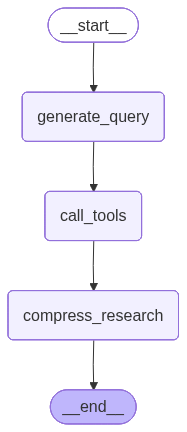

In [45]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [46]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""


with tracer.start_as_current_span("tool_search"):
    result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})

format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance.         │
│ My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their     │
│ ambiance,                                                                                                       │
│ including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified          │
│ preferences                                                                                                     │
│ regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities,  │
│ so these                                                                                                        │
│ should be considered flexible unless they are relevant to ambiance. Please prioritize information from official │
│ coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible   │
│ local                                                                                                           │
│ publications. The research should be current as of October 2025..                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shops in Seattle with unique ambiance 2025 site:yelp.com"                               │
│ }                                                                                                               │
│    ID: call_8zXQvgxsbgG8yh6R0llPI7TV                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "top coffee shop atmosphere Seattle 2025 site:tripadvisor.com"                                       │
│ }                                                                                                               │
│    ID: call_mQbQFsfaBNZ0iRLrjzBH6No8                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shop ambiance Seattle 2025 site:seattletimes.com"                                       │
│ }                                                                                                               │
│    ID: call_zboGckzFoiusZ6mAB5EPdEYu                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Seattle coffee shops interior design and vibe 2025"                                                 │
│ }                                                                                                               │
│    ID: call_LqTS3tDYY5QYZx6pwxAy4yy3                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Best Unique Coffee Shops near Downtown, Seattle, WA ---                                           │
│ URL: https://m.yelp.com/search?find_desc=Unique+Coffee+Shops&find_loc=Downtown%2C+Seattle%2C+WA                 │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Unique Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Ghost Note Coffee, Ghost  │
│ Alley Espresso, Moore Coffee Shop,                                                                              │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Top 10 Best Unique Coffee Shops Near Seattle, Washington ---                                      │
│ URL: https://www.yelp.com/search?find_desc=Unique+Coffee+Shops&find_loc=Seattle%2C+WA                           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Unique Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Ghost Note Coffee,        │
│ Coffeeholic House, Moore Coffee Shop,                                                                           │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: TOP 10 BEST Coffee in Seattle, WA - Updated 2025 ---                                              │
│ URL: https://www.yelp.com/search?find_desc=Coffee&find_loc=Seattle%2C+WA                                        │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Coffee in Seattle, WA - Last Updated September 2025 - Yelp - Storyville Coffee Company, Drip Drip   │
│ Coffeehouse, Anchorhead Coffee - CenturyLink                                                                    │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: THE 10 BEST Cafés in Seattle (Updated 2025) ---                                                   │
│ URL: https://www.tripadvisor.com/Restaurants-g60878-c8-Seattle_Washington.html                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 1. Bakery Nouveau. 4.8. (1,270 reviews). Bakeries, French$$ - $$$ · 2. Storyville Coffee Pike Place. 4.7. (386  │
│ reviews) · 3. Le Panier. 4.6.                                                                                   │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Starbucks Reserve Roastery Seattle (2025) ---                                                     │
│ URL:                                                                                                            │
│ https://www.tripadvisor.com/Attraction_Review-g60878-d7321281-Reviews-or10-Starbucks_Reserve_Roastery_Seattle-S │
│ eattle_Washington.html                                                                                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ It is an immersive and dramatic expression of our passion for coffee, located just nine blocks from our         │
│ original Starbucks Pike Place store.                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: The Best Places to Study in Capitol Hill - The Ticket Seattle ---                                 │
│ URL: https://theticket.seattletimes.com/city-guides/where-to-study-in-capitol-hill/                             │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage is a detailed guide by Haylee Jarrett on the best places to study in Capitol Hill, Seattle, updated │
│ as of October 4, 2022. It addresses the challenge of finding late-night coffee shops suitable for study due to  │
│ pandemic-related changes and staffing issues. The guide highlights a variety of venues including Top Pot        │
│ Doughnuts, Optimism Brewing, Tailwind Cafe inside Good Weather Bicycles, Chophouse Row, Whole Foods, and Drip   │
│ Tea, detailing each spot’s atmosphere, hours, amenities like WiFi and power outlets, and food and beverage      │
│ offerings. Notably, Optimism Brewing stays open late and accommodates groups and dogs, while Tailwind Cafe      │
│ offers a cozy environment with a fire pit and stays open until 9 pm most nights. The guide also mentions        │
│ smaller outlets and public spaces such as the Seattle Public Library Capitol Hill Branch and others. The author │
│ encourages readers to suggest favorite study spots via email, and the webpage is part of a larger series of     │
│ neighborhood guides produced by The Seattle Times.                                                              │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ "Post-2020, finding places with the right vibes for a cram or study session has been rough...lots of places now │
│ shut down earlier than they used to—or they just shut down permanently.", "Optimism Brewing: A 16,000-square    │
│ feet industrial space used primarily as a group hangout spot works surprisingly well for work-from-homies and   │
│ students alike.", "Tailwind Cafe is a comfy little coffee shop run out of Good Weather Bicycle & Cafe...You can │
│ do your required reading by the fire pit!", "Whole Foods seating area is open until 9 pm, with a ton of outlets │
│ and open WiFi, making it a viable public study spot.", "Drip Tea is the designated cool boba of Capitol Hill,   │
│ open until 10 pm on Fridays and Saturdays and 9 pm other days, great for late study sessions."                  │
│ </key_excerpts>                                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                        

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: TOP 10 BEST Aesthetic Cafe in Seattle, WA - Updated 2025 - Yelp ---                               │
│ URL: https://www.yelp.com/search?find_desc=Aesthetic+Cafe&find_loc=Seattle%2C+WA                                │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Aesthetic Cafe Near Seattle, Washington · 1. Santo Coffee · 2. Phe · 3. Café Hagen · 4. Koto Jelly  │
│ Coffee · 5. Cafe An'Clair · 6. Nana's Green Tea · 7.                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Seattle girlies ‍♀️ here are 4 Seattle coffee shops to visit in 2025 ---                            │
│ URL: https://www.instagram.com/reel/DEELjwvxYun/?hl=en                                                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 260 likes, 17 comments - emmasedition on December 26, 2024: "Seattle girlies ‍♀️ here are 4 Seattle coffee shops  │
│ to visit in 2025: ☕️ Aroom                                                                                      │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: Seattle Coffee Culture at Home: Cozy Vibes with MSR Communities ---                               │
│ URL: https://msrcommunities.com/blog/seattle-coffee-culture/                                                    │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage highlights Seattle's vibrant coffee culture, emphasizing the city's numerous cafes that serve as    │
│ social hubs and urban sanctuaries. It explores how MSR Communities integrates this coffee shop ambiance into    │
│ their home designs, offering cozy coffee corners, ample natural light, warm and textured interiors, and outdoor │
│ spaces that emulate cafe vibes. MSR homes blend modern functionality with the charm of local coffee shops,      │
│ allowing residents to enjoy both external cafe cult

In [47]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 1 Search for "best coffee shops in Seattle with unique ambiance 2025 site:yelp.com"                               
 2 Search for "top coffee shop atmosphere Seattle 2025 site:tripadvisor.com"                                       
 3 Search for "best coffee shop ambiance Seattle 2025 site:seattletimes.com"                                       
 4 Search for "Seattle coffee shops interior design and vibe 2025"                                                 
 5 Search for "TOP 10 BEST Aesthetic Cafe in Seattle, WA - Updated 2025 - Yelp"                                    
 6 Search for "Seattle girlies here are 4 Seattle coffee shops to visit in 2025"                                   
 7 Search for "Seattle Coffee Culture at Home: Cozy Vibes with MSR Communities"                                    

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

 • Top 10 Best Unique Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Ghost Note Coffee, Ghost  
   Alley Espresso, Moore Coffee Shop [1].                                                                          
 • Top 10 Best Unique Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Ghost Note Coffee,        
   Coffeeholic House, Moore Coffee Shop [2].                                                                       
 • Top 10 Best Coffee in Seattle, WA - Last Updated September 2025 - Yelp - Storyville Coffee Company, Drip Drip   
   Coffeehouse, Anchorhead Coffee - CenturyLink [3].                                                               
 • THE 10 BEST Cafés in Seattle (Updated 2025) - Bakery Nouveau. 4.8. (1,270 reviews). Bakeries, French$$ - $$$.   
   Storyville Coffee Pike Place. 4.7. (386 reviews). Le Panier. 4.6. [4].                                          
 • Starbucks Reserve Roastery Seattle (2025) - It is an immersive and dramatic expression of our passion for       
   coffee, located just nine blocks from our original Starbucks Pike Place store [5].                              
 • The webpage is a detailed guide by Haylee Jarrett on the best places to study in Capitol Hill, Seattle, updated 
   as of October 4, 2022. It addresses the challenge of finding late-night coffee shops suitable for study due to  
   pandemic-related changes and staffing issues. The guide highlights a variety of venues including Top Pot        
   Doughnuts, Optimism Brewing, Tailwind Cafe inside Good Weather Bicycles, Chophouse Row, Whole Foods, and Drip   
   Tea, detailing each spot’s atmosphere, hours, amenities like WiFi and power outlets, and food and beverage      
   offerings. Notably, Optimism Brewing stays open late and accommodates groups and dogs, while Tailwind Cafe      
   offers a cozy environment with a fire pit and stays open until 9 pm most nights. The guide also mentions smaller
   outlets and public spaces such as the Seattle Public Library Capitol Hill Branch and others. The author         
   encourages readers to suggest favorite study spots via email, and the webpage is part of a larger series of     
   neighborhood guides produced by The Seattle Times. “Post-2020, finding places with the right vibes for a cram or
   study session has been rough...lots of places now shut down earlier than they used to—or they just shut down    
   permanently.” “Optimism Brewing: A 16,000-square feet industrial space used primarily as a group hangout spot   
   works surprisingly well for work-from-homies and students alike.” “Tailwind Cafe is a comfy little coffee shop  
   run out of Good Weather Bicycle & Cafe...You can do your required reading by the fire pit!” “Whole Foods seating
   area is open until 9 pm, with a ton of outlets and